In [1]:
import scipy.integrate as itg
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def acc(v): 
    x, y, z = v[0], v[1], v[2]
    R = np.sqrt(x**2 + y**2 + z**2) # kpc units
    truncation = 100
    R = np.minimum(R, truncation)
    R  = max(R, 1e-6)
    
    # Central mass
    M1 = 606.
    b1 = 0.3873
    
    dphi_x1 =  M1*x/(x**2 + y**2 + z**2 + b1**2)**(3/2)
    dphi_y1 =  M1*y/(x**2 + y**2 + z**2 + b1**2)**(3/2)
    dphi_z1 =  M1*z/(x**2 + y**2 + z**2 + b1**2)**(3/2) 
    
    # Disk component
    M2 = 3690.
    a2 = 5.3178
    b2 = 0.25
    
    dphi_x2 = M2*x / (x**2 + y**2 + (a2 + np.sqrt(z**2 + b2**2))**2)**(3/2)
    dphi_y2 = M2*y / (x**2 + y**2 + (a2 + np.sqrt(z**2 + b2**2))**2)**(3/2)
    dphi_z2 = M2*z*(a2 + np.sqrt(z**2 + b2**2))/(np.sqrt(z**2 + b2**2)*(np.sqrt(x**2 + y**2 + (a2 + np.sqrt(z**2 + b2**2))**2))**3)
    
    # Halo
    M3 = 4615.
    a3 = 12.

    def halo(x):
        a = -(1.02*M3*(x/R))*((R/a3)**2.02)
        b = R*(1+(R/a3)**1.02)
        
        c = M3 * x * ((R/a3)**(1.02)) / (a3 * R**2)
        d = 1 + (R/a3)**(1.02)
        
        halo = c / d
        return halo
    
    dphi_x3 = halo(x)
    dphi_y3 = halo(y)
    dphi_z3 = halo(z)
    
    dphi_x = dphi_x1 + dphi_x2 + dphi_x3
    dphi_y = dphi_y1 + dphi_y2 + dphi_y3
    dphi_z = dphi_z1 + dphi_z2 + dphi_z3

    acx, acy, acz = -dphi_x, -dphi_y, -dphi_z
    return np.array([acx, acy, acz])

def f(t, state):
    x, y, z, vx, vy, vz = state
    v = np.array([x,y,z])
    ax, ay, az = acc(v)
    return np.array([vx, vy, vz, ax, ay, az])

In [3]:
kpc = 1.0                 # already in code length units
kms_to_code = 1.0/10.0    # 1 code velocity unit = 10 km/s

x0, y0_, z0 = 8.0, 0.0, 0.021         # kpc: R ~ 8 kpc, slightly above the plane
vx0, vy0, vz0 = 0.0*kms_to_code, 220.0*kms_to_code, 0.0*kms_to_code  # km/s -> code units

state0 = np.array([x0, y0_, z0, vx0, vy0, vz0])

# Integration will be till 5 Gyrs
time_unit_Gyr = 0.0978
t_end_Gyr = 5
t_end = t_end_Gyr / time_unit_Gyr  # Code units

h = 0.00005
number_steps = int(t_end/h)

In [4]:
solver = itg.RK45(f, 0, state0, t_end, max_step = 0.0005)
"""
Here: 
    - f is the dynamical system to solve
    - t0 is the initial time
    - y0 is the initial state
    - t_bound is the final time of integration
    - max_step is the maximum value for the integration step
Recall that this method has adaptive step, which means it will select the best 
step in each iterarion given its consideration (mathematically)
"""

'\nHere: \n    - f is the dynamical system to solve\n    - t0 is the initial time\n    - y0 is the initial state\n    - t_bound is the final time of integration\n    - max_step is the maximum value for the integration step\nRecall that this method has adaptive step, which means it will select the best \nstep in each iterarion given its consideration (mathematically)\n'

In [5]:
ts, soly = [solver.t], [solver.y.copy()]

while solver.status == 'running':
    solver.step()               # advances one adaptive RK45 step
    ts.append(solver.t)
    soly.append(solver.y.copy())

soly = np.array(soly)

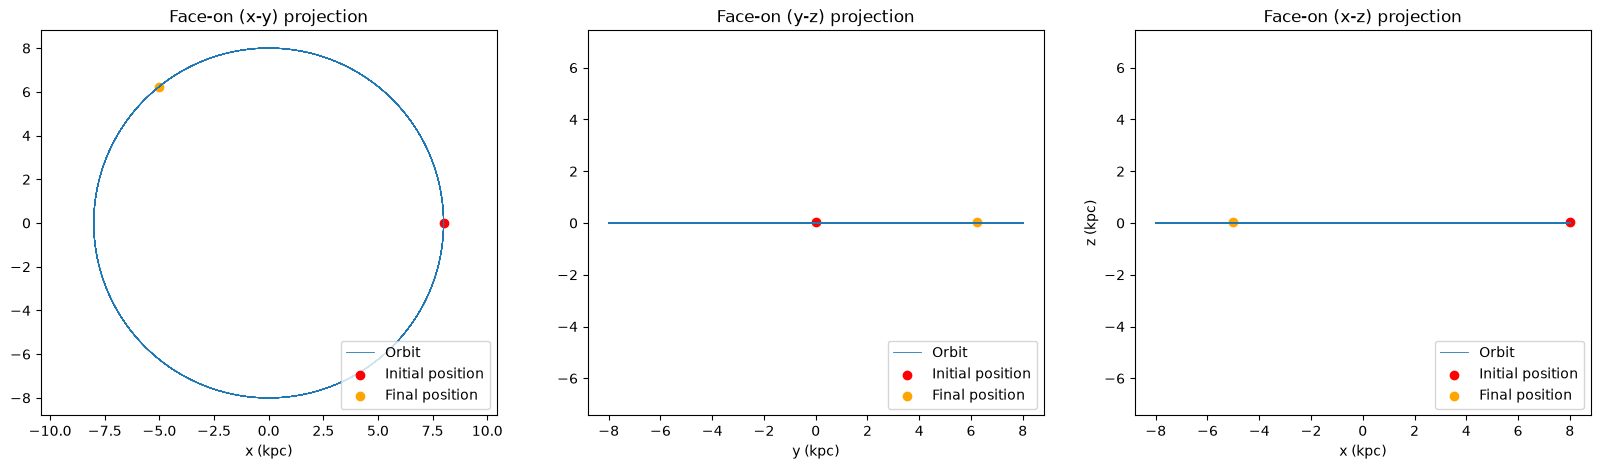

In [6]:
fig, axes = plt.subplots(1, 3, figsize = (20,5))

axes[0].plot(soly[:,0], soly[:,1], lw=0.6, label = "Orbit")
axes[0].scatter(state0[0], state0[1], color = "r", label = "Initial position")
axes[0].scatter(soly[-1,0], soly[-1,1], color = "orange", label = "Final position")
axes[0].set_xlabel('x (kpc)'); plt.ylabel('y (kpc)')
axes[0].set_title('Face-on (x-y) projection')
axes[0].legend(loc = 4)
axes[0].axis("equal")

axes[1].plot(soly[:,1], soly[:,2], lw=0.6, label = "Orbit")
axes[1].scatter(state0[1], state0[2], color = "r", label = "Initial position")
axes[1].scatter(soly[-1,1], soly[-1,2], color = "orange", label = "Final position")
axes[1].set_xlabel('y (kpc)'); plt.ylabel('z (kpc)')
axes[1].set_title('Face-on (y-z) projection')
axes[1].legend(loc = 4)
axes[1].axis("equal")

axes[2].plot(soly[:,0], soly[:,2], lw=0.6, label = "Orbit")
axes[2].scatter(state0[0], state0[2], color = "r", label = "Initial position")
axes[2].scatter(soly[-1,0], soly[-1,2], color = "orange", label = "Final position")
axes[2].set_xlabel('x (kpc)'); plt.ylabel('z (kpc)')
axes[2].set_title('Face-on (x-z) projection')
axes[2].legend(loc = 4)
axes[2].axis("equal")

#plt.savefig("./images/orbits_each_planeRK45.png")
plt.show()

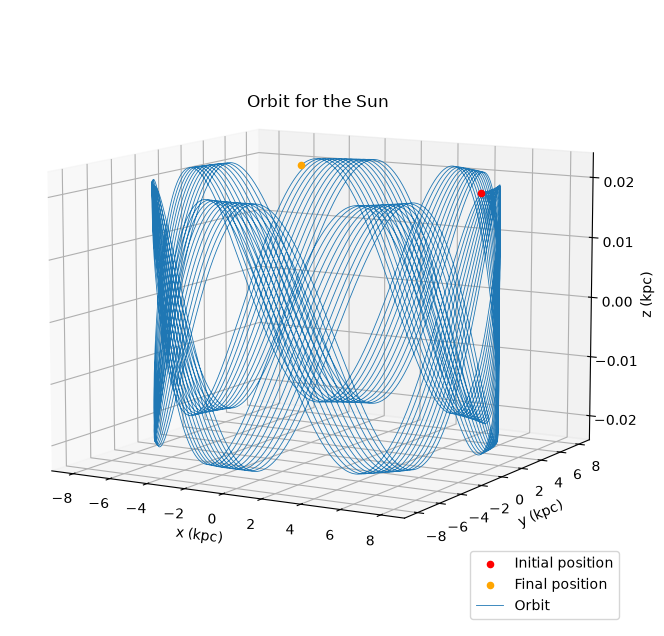

In [7]:
fig = plt.figure(figsize = (8,8),)
ax = fig.add_subplot(projection='3d')
ax.scatter(state0[0], state0[1], state0[2], color = "r", label = "Initial position")
ax.scatter(soly[-1,0], soly[-1,1], soly[-1,2], color = "orange", label = "Final position")
ax.plot(soly[:,0], soly[:,1], soly[:,2], lw = 0.6, label = "Orbit")
ax.view_init(elev=10, azim = None, roll=0)
ax.set_xlabel("x (kpc)")
ax.set_ylabel("y (kpc)")
ax.set_zlabel("z (kpc)")
ax.legend(loc = 4)
ax.set_title("Orbit for the Sun", y = 0.95, pad = -14)
#plt.savefig("./images/órbita3dRK45.png")
plt.show()

In [8]:
def pot(v):
    m1, b1 = 606., 0.3873
    m2, a2, b2 = 3690., 5.3178, .25
    m3, a3 = 4615., 12.0

    x, y, z = v[0], v[1], v[2]
    R = np.sqrt(x**2 + y**2 + z**2)
    omega = np.sqrt(x**2 + y**2)

    M_R = m3*(R/a3)**(2.02)/(1 + (R/a3)**(1.02))
    term1 = -(1.02)/(1 + (100/a3)**(1.02)) + np.log(1 + (100/a3)**(1.02))
    term2 = -(1.02)/(1 + (R/a3)**(1.02)) + np.log(1 + (R/a3)**(1.02))
        
    phi1 = -m1/ np.sqrt(R**2 +b1**2)
    phi2 = -m2 / np.sqrt(omega**2 + (a2 + np.sqrt(z**2 + b2**2))**2)
    phi3 = -M_R/R - (m3/(1.02 * a3)) * (term1 - term2)

    phi = phi1 + phi2 + phi3
    return phi

def T(v):
    vx, vy, vz = v[3], v[4], v[5]
    t = (1/2)*(vx**2 + vy**2 + vz**2)
    return t
    
def l(v):
    r = np.array([v[0], v[1], v[2]])
    v = np.array([v[3], v[4], v[5]])
    l = np.cross(r, v)
    return l

def err(v1, v2): 
    err = np.abs(v1 - v2)/np.abs(v2)
    return err

In [9]:
# Relative error in initial and final energy

e0 = T(state0) + pot(state0)
ef = T(soly[-1]) + pot(soly[-1])

error = err(e0, ef)
print(error)

1.8045198759424125e-14


In [10]:
l0 = l(state0); lz_0 = l0[2]
lf = l(soly[-1]); lz_f = lf[2]

error_lz = err(lz_0, lz_f)
print(error_lz)

4.521635591200433e-14


<Figure size 5000x2000 with 0 Axes>

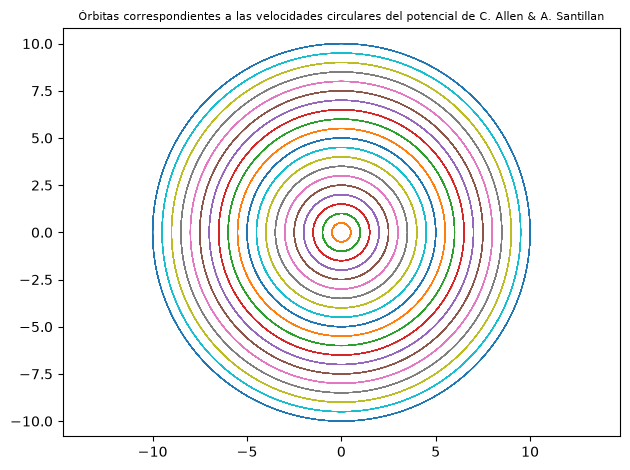

In [11]:
def vel_c(v, code_units = True):
    ac = acc(v)
    x, y, z = v[0], v[1], v[2]
    if code_units == False:
        vel = np.sqrt(-ac[0]*x - ac[1]*y - ac[2]*z)*10
    else:
        vel = np.sqrt(-ac[0]*x - ac[1]*y - ac[2]*z)
    return vel

r = np.linspace(0, 10, 21) # kpc
states = np.zeros((21,6))

fig = plt.figure(figsize = (50,20),)
fig, ax = plt.subplots()

for i in range(21):
    states[i, 0] = r[i]
    pos = np.array([r[i], 0, 0]) 
    
    cir_v = vel_c(pos)
    states[i,4] = cir_v

    x0, y0_, z0 = states[i,0], states[i,1], states[i,2]
    vx0, vy0, vz0 = states[i,3], states[i,4], states[i,5]
    state0 = np.array([x0, y0_, z0, vx0, vy0, vz0])
    
    time_unit_Gyr = 0.0978
    h = 0.0005
    t_end_Gyr = 5
    t_end = t_end_Gyr / time_unit_Gyr
    
    solver = itg.RK45(f, 0, state0, t_end, max_step = h)
    ts, ys = [solver.t], [solver.y.copy()]

    while solver.status == 'running':
        solver.step()              
        ts.append(solver.t)
        ys.append(solver.y.copy())
    
    ys1 = np.array(ys)

    ax.plot(ys1[:,0], ys1[:,1], lw = 0.6)
ax.set_title("Órbitas correspondientes a las velocidades circulares del potencial de C. Allen & A. Santillan",
            fontsize = 8)
ax.axis("equal")
plt.tight_layout()
#plt.savefig("./images/rotation_curve_orbits(0)RK45.png")
plt.show()

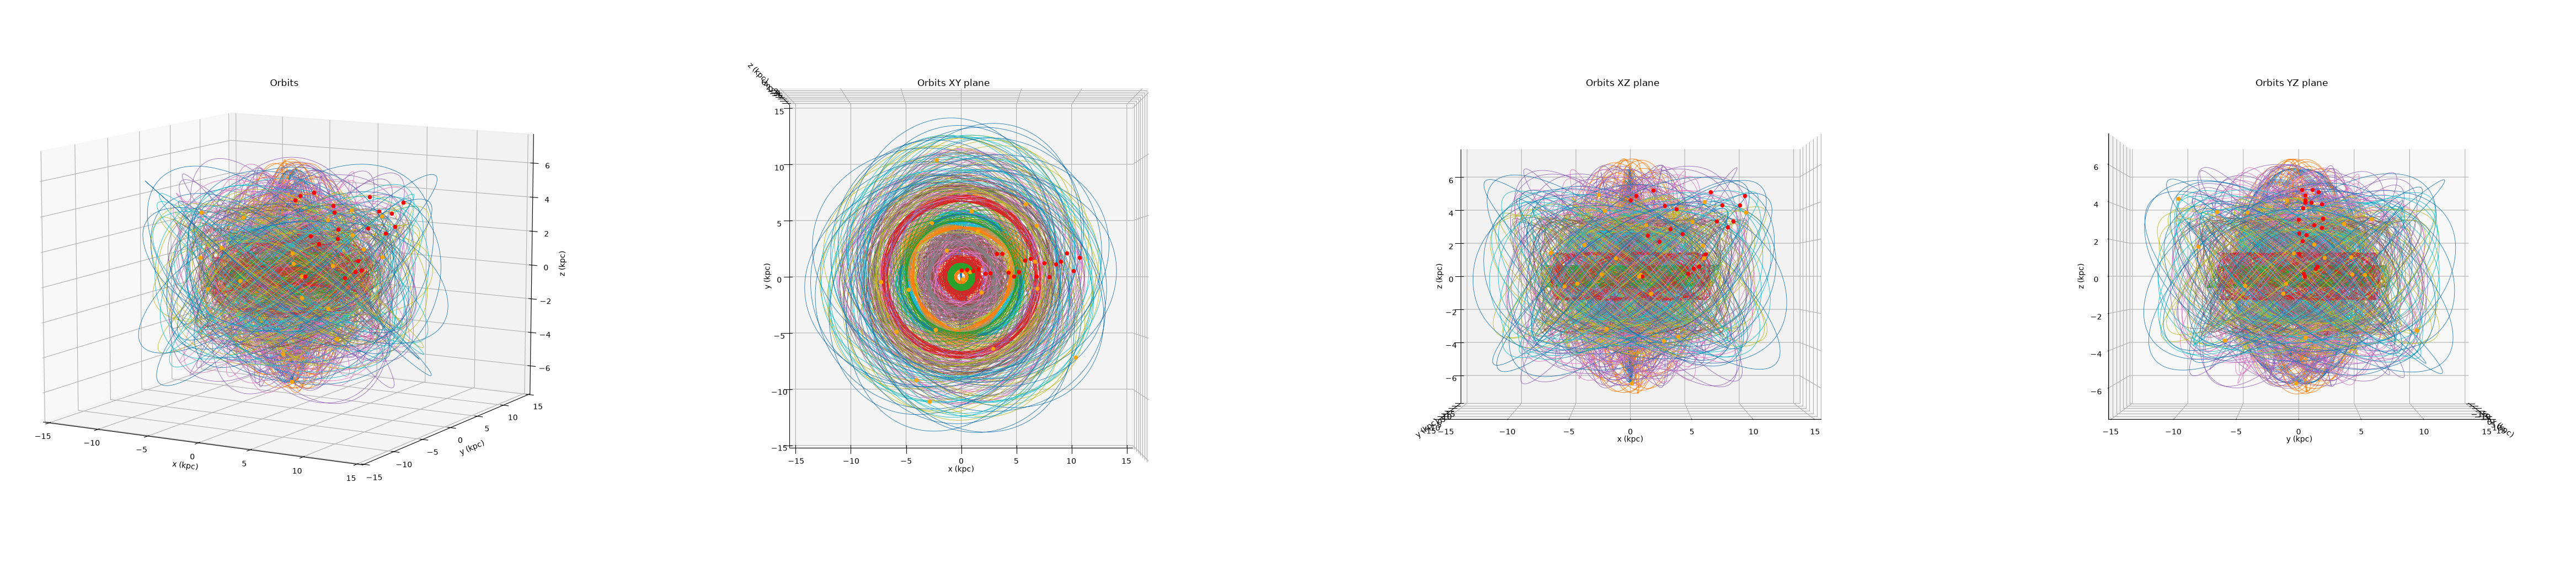

In [16]:
np.random.seed(5)

vx = np.random.rand(21)*5

y = np.random.rand(21)*2

z = np.random.rand(21)*5
vz = np.random.rand(21)*3

fig = plt.figure(figsize = (60,60),)

ax = fig.add_subplot(1, 4, 1, projection='3d')
ax.view_init(elev = 10, azim = None, roll = 0)

errors_E = []
errors_lz = []

for i in range(21):
    states[i, 0] = r[i]
    states[i, 1] = y[i]
    states[i, 2] = z[i]
    pos = np.array([r[i], y[i], z[i]]) 
    
    cir_v = vel_c(pos)
    states[i,3] = vx[i]
    states[i,4] = cir_v
    states[i,5] = vz[i]

    x0, y0_, z0 = states[i,0], states[i,1], states[i,2]
    vx0, vy0, vz0 = states[i,3], states[i,4], states[i,5]
    state0 = np.array([x0, y0_, z0, vx0, vy0, vz0])
    
    time_unit_Gyr = 0.0978
    h = 0.0005
    t_end_Gyr = 5
    t_end = t_end_Gyr / time_unit_Gyr
    
    solver = itg.RK45(f, 0, state0, t_end, max_step = h)
    ts, ys = [solver.t], [solver.y.copy()]

    while solver.status == 'running':
        solver.step()              
        ts.append(solver.t)
        ys.append(solver.y.copy())
    
    ys = np.array(ys)

    ax.plot(ys[:,0], ys[:,1], ys[:,2], lw = 0.6,)
    ax.scatter(state0[0], state0[1], state0[2], color = "r",)
    ax.scatter(ys[-1,0], ys[-1,1], ys[-1,2], color = "orange",)
    
ax.set_xlabel("x (kpc)")
ax.set_ylabel("y (kpc)")
ax.set_zlabel("z (kpc)")
ax.set_title("Orbits", y = 0.95, pad = -14)

ax = fig.add_subplot(1, 4, 2, projection='3d')
ax.view_init(elev = 90, azim = -90, roll = 0)

for i in range(21):
    states[i, 0] = r[i]
    states[i, 1] = y[i]
    states[i, 2] = z[i]
    pos = np.array([r[i], y[i], z[i]]) 
    
    cir_v = vel_c(pos)
    states[i,3] = vx[i]
    states[i,4] = cir_v
    states[i,5] = vz[i]

    x0, y0_, z0 = states[i,0], states[i,1], states[i,2]
    vx0, vy0, vz0 = states[i,3], states[i,4], states[i,5]
    state0 = np.array([x0, y0_, z0, vx0, vy0, vz0])
    
    time_unit_Gyr = 0.0978
    h = 0.0005
    t_end_Gyr = 5
    t_end = t_end_Gyr / time_unit_Gyr

    solver = itg.RK45(f, 0, state0, t_end, max_step = h)
    ts, ys = [solver.t], [solver.y.copy()]

    while solver.status == 'running':
        solver.step()              
        ts.append(solver.t)
        ys.append(solver.y.copy())
    
    ys = np.array(ys)

    ax.plot(ys[:,0], ys[:,1], ys[:,2], lw = 0.6,)
    ax.scatter(state0[0], state0[1], state0[2], color = "r",)
    ax.scatter(ys[-1,0], ys[-1,1], ys[-1,2], color = "orange",)
    
ax.set_xlabel("x (kpc)")
ax.set_ylabel("y (kpc)")
ax.set_zlabel("z (kpc)")
ax.set_title("Orbits XY plane", y = 0.95, pad = -14)

ax = fig.add_subplot(1, 4, 3, projection='3d')
ax.view_init(elev = 0, azim = -90, roll = 0)

for i in range(21):
    states[i, 0] = r[i]
    states[i, 1] = y[i]
    states[i, 2] = z[i]
    pos = np.array([r[i], y[i], z[i]]) 
    
    cir_v = vel_c(pos)
    states[i,3] = vx[i]
    states[i,4] = cir_v
    states[i,5] = vz[i]

    x0, y0_, z0 = states[i,0], states[i,1], states[i,2]
    vx0, vy0, vz0 = states[i,3], states[i,4], states[i,5]
    state0 = np.array([x0, y0_, z0, vx0, vy0, vz0])
    
    time_unit_Gyr = 0.0978
    h = 0.0005
    t_end_Gyr = 5
    t_end = t_end_Gyr / time_unit_Gyr

    solver = itg.RK45(f, 0, state0, t_end, max_step = h)
    ts, ys = [solver.t], [solver.y.copy()]

    while solver.status == 'running':
        solver.step()              
        ts.append(solver.t)
        ys.append(solver.y.copy())
    
    ys = np.array(ys)

    ax.plot(ys[:,0], ys[:,1], ys[:,2], lw = 0.6,)
    ax.scatter(state0[0], state0[1], state0[2], color = "r",)
    ax.scatter(ys[-1,0], ys[-1,1], ys[-1,2], color = "orange",)
    
ax.set_xlabel("x (kpc)")
ax.set_ylabel("y (kpc)")
ax.set_zlabel("z (kpc)")
ax.set_title("Orbits XZ plane", y = 0.95, pad = -14)
    
ax = fig.add_subplot(1, 4, 4, projection='3d')
ax.view_init(elev = 0, azim = 0, roll = 0)

for i in range(21):
    states[i, 0] = r[i]
    states[i, 1] = y[i]
    states[i, 2] = z[i]
    pos = np.array([r[i], y[i], z[i]]) 
    
    cir_v = vel_c(pos)
    states[i,3] = vx[i]
    states[i,4] = cir_v
    states[i,5] = vz[i]

    x0, y0_, z0 = states[i,0], states[i,1], states[i,2]
    vx0, vy0, vz0 = states[i,3], states[i,4], states[i,5]
    state0 = np.array([x0, y0_, z0, vx0, vy0, vz0])
    
    time_unit_Gyr = 0.0978
    h = 0.0005
    t_end_Gyr = 5
    t_end = t_end_Gyr / time_unit_Gyr

    solver = itg.RK45(f, 0, state0, t_end, max_step = h)
    ts, ys = [solver.t], [solver.y.copy()]

    while solver.status == 'running':
        solver.step()              
        ts.append(solver.t)
        ys.append(solver.y.copy())
    
    ys = np.array(ys)

    ax.plot(ys[:,0], ys[:,1], ys[:,2], lw = 0.6,)
    ax.scatter(state0[0], state0[1], state0[2], color = "r",)
    ax.scatter(ys[-1,0], ys[-1,1], ys[-1,2], color = "orange",)

    e0 = T(state0) + pot(state0)
    ef = T(ys[-1]) + pot(ys[-1])
    
    error = err(e0, ef)
    errors_E.append(error.item)
    
    l0 = l(state0); lz_0 = l0[2]
    lf = l(ys[-1]); lz_f = lf[2]
    
    error_lz = err(lz_0, lz_f)
    errors_lz.append(error_lz.item())
    
ax.set_xlabel("x (kpc)")
ax.set_ylabel("y (kpc)")
ax.set_zlabel("z (kpc)")
ax.set_title("Orbits YZ plane", y = 0.95, pad = -14)

plt.savefig("./images/órbitas3d(1)RK45.png")
plt.show()

In [19]:
print("y's: ", y, "\nz's: ", z)

y's:  [0.53163824 0.56937176 0.50717641 0.6551279  0.2883286  0.33122572
 1.92786106 1.92045343 0.37682931 0.04861312 0.40911109 1.39968723
 1.55902917 0.04586618 1.15532572 0.00328435 1.03094522 1.27959035
 1.97124881 0.51819519 1.60499377] 
z's:  [4.35241544 4.61374807 0.01107106 2.34744186 4.90734369 1.99472402
 4.06866239 2.73228249 3.85427044 2.42465537 0.14555782 0.43262844
 0.55726906 1.25622556 4.82457646 3.15883026 4.08330101 2.83040998
 3.17678103 4.05951196 4.63341308]


In [18]:
print("Errores relativos en el valor de la energía: ", errors_E)
print("Errores relativos en el valor del momento angular: ", errors_lz)

Errores relativos en el valor de la energía:  [<built-in method item of numpy.float64 object at 0x70371f6effd0>, <built-in method item of numpy.float64 object at 0x70371f3e3fd0>, <built-in method item of numpy.float64 object at 0x70371f95be70>, <built-in method item of numpy.float64 object at 0x7037233d3e50>, <built-in method item of numpy.float64 object at 0x70371f833c30>, <built-in method item of numpy.float64 object at 0x7037233d0110>, <built-in method item of numpy.float64 object at 0x70371f8300d0>, <built-in method item of numpy.float64 object at 0x7037233d0410>, <built-in method item of numpy.float64 object at 0x70371f830410>, <built-in method item of numpy.float64 object at 0x7037233d17b0>, <built-in method item of numpy.float64 object at 0x70371f8306b0>, <built-in method item of numpy.float64 object at 0x7037233d0930>, <built-in method item of numpy.float64 object at 0x70371f830930>, <built-in method item of numpy.float64 object at 0x7037233d0bb0>, <built-in method item of nump